<style>
/* Constrain image heights to keep figures from blowing out pages. */
.jp-RenderedImage img, .output_png img, .output_subarea img { max-height: 3.5in; width: auto; }
/* Tighten paragraph spacing and font slightly. */
body, .jp-Notebook { font-size: 10.5pt; }
p { margin: 0.4em 0; }
ul, ol { margin: 0.4em 0; }
h1 { font-size: 16pt; margin-top: 0.6em; margin-bottom: 0.4em; }
h2 { font-size: 13pt; margin-top: 0.6em; margin-bottom: 0.3em; }
h3 { font-size: 11.5pt; margin-top: 0.5em; margin-bottom: 0.25em; }
pre, code { font-size: 9pt; }
table { font-size: 9.5pt; }
</style>


# SVG Scaling Laws

Toan Vu
---

## Abstract

I trained five decoder-only transformer models, with sizes ranging from 1M to 36M parameters, on a cleaned 68M-token SVG dataset. I did this twice: once with standard parameterization (SP) using a learning rate picked from a sweep, and once with muP using a learning rate that was tuned only on the smallest model and reused for all the bigger ones. The main finding: with SP and a fixed LR, scaling actually goes the wrong way, but with muP the LR transfers cleanly so `mup_xl` ends up about the same as `mup_tiny`.

I also looked at generation quality. The 36M muP model trained for 3 epochs gets test perplexity 481 and 17.8% well-formed XML output. To check whether more training fixes generation, Appendix D pushes past Chinchilla with `tiny_long`, `large_long`, and `xl_long`. Test perplexity drops all the way to 24, but render rate stays stuck between 7-20% in every run.


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == 'report' else Path.cwd()
RUNS = ROOT / 'runs'
FIGS = ROOT / 'report' / 'figures'
DATA_EX = FIGS / 'data_examples'

def _try_json(path):
    try: return json.loads(path.read_text(encoding='utf-8'))
    except Exception: return None
def _try_csv(path):
    try: return pd.read_csv(path)
    except Exception: return pd.DataFrame()

scaling_table = _try_csv(FIGS / 'scaling_runs_table.csv')
sp_summary    = _try_json(RUNS / 'sp_scaling_summary.json')
mup_summary   = _try_json(RUNS / 'mup_scaling_summary.json')
sp_sweep      = _try_json(RUNS / 'sweep_sp_tiny'  / 'sweep_results.json')
mup_sweep     = _try_json(RUNS / 'sweep_mup_tiny' / 'sweep_results.json')
best_run_id   = (RUNS / 'best_run_id.txt').read_text(encoding='utf-8').strip() if (RUNS / 'best_run_id.txt').exists() else None
eval_data     = _try_json(RUNS / f'eval_{best_run_id}.json') if best_run_id else None
data_stats    = _try_json(ROOT / 'data' / 'splits'    / 'stats.json')
tok_stats     = _try_json(ROOT / 'data' / 'tokenizer' / 'stats.json')
seq_stats     = _try_json(ROOT / 'data' / 'splits'    / 'seqlen_hist.json')
data_ex_man   = _try_json(DATA_EX / 'manifest.json')
samples_man   = _try_json(RUNS / 'samples' / best_run_id / 'manifest.json') if best_run_id else None

print('artifacts loaded')

artifacts loaded


## 1. Introduction

Scaling laws describe how a language model's loss drops as you grow the model and add more training tokens, but  hyperparameters have to be re-tuned at every scale. Under standard parameterization (SP), the best learning rate shifts with model width, so an LR that works on a small model isn't right for a bigger one. Yang et al. (2022) introduced muP to fix this: with the right initialization, attention scaling (1/d instead of 1/sqrt(d)), and per-parameter LR multipliers, the best LR becomes width-invariant, so an LR tuned on a small "proxy" model transfers to wider models without re-tuning.

This project tests whether muP works on SVG, which is a useful target because it isn't natural language. SVG is XML-based code with tags, attributes, and dense numeric path strings, so I can check the model's output for two things: does it predict the next token well, and does the output actually parse and render?

What I did was train five sizes per parameterization (SP and muP), show that SP with a fixed LR scales the wrong way at my compute budget while muP doesn't, check the muP code with a coordinate test, and train one "best" model and look at how its generated SVGs hold up. The architecture and the AdamW decay-vs-no-decay parameter group trick come from Karpathy's nanoGPT. The muP variant, the YAML config system, and the analysis are mine.


## 2. Data

**Corpus.** I pulled three HuggingFace datasets through `datasets.load_dataset`: `starvector/svg-icons-simple` (~89k files), `starvector/svg-emoji-simple` (~50k files), and `starvector/svg-fonts-simple` randomly subsampled to 500k rows (with a fixed seed so it's reproducible). After cleaning, I had about 580k SVGs.

**Cleaning.** Each SVG goes through `lxml.etree.fromstring` in strict mode, and anything that fails to parse is dropped. I strip out namespaces other than the default SVG one and xlink, throw away `<metadata>`, `<title>`, and `<desc>`, and round numeric attributes (`d`, `points`, `cx`, `cy`, `transform`, `viewBox`, etc.) to one decimal using a regex that matches numbers but leaves command letters alone. I also drop SVGs shorter than 50 characters or longer than 8000.

**Splits.** I shuffle the cleaned records with seed 0 and split them 98/1/1 *by file* (not by token position), giving about 572k train / 5.8k val / 5.8k test SVGs.

**Tokenizer.** A 4096-vocab byte-level BPE from HuggingFace `tokenizers`, trained on a 100k-record subset of the train split (BPE statistics converge quickly, so using the full corpus would have wasted hours of CPU). The one important setting was `use_regex=False` on the ByteLevel pre-tokenizer. With the default GPT-2 regex turned on, path-d strings like `M3 12L8` get pre-split into separate pieces `[M, 3, 12, L, 8]` and BPE can't merge across them, which dropped compression to about 1.8 chars/token. Turning the regex off lets BPE see the whole byte stream and gets compression up to about 7.6 chars/token, roughly 4x better, with the same vocab size.


### 2.1 Sequence-length distribution

Token-count histogram on the train split (one bar per SVG). Most files sit well below the 1024-token block size (p99 around 540, max around 2150), with a long tail from the bigger font glyphs.


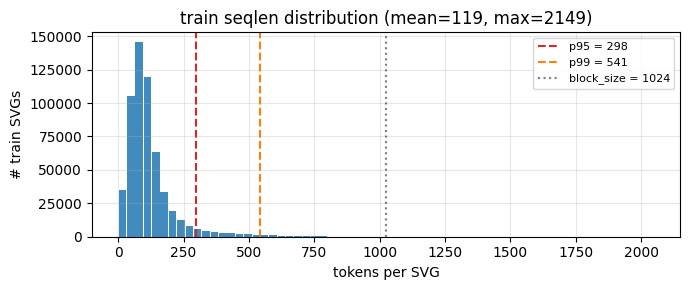


| split | records | tokens | mean | p95 | p99 | max |
|---|---|---|---|---|---|---|
| train | 572,753 | 68,514,166 | 119 | 298 | 541 | 2149 |
| val | 5,844 | 709,716 | 120 | 300 | 554 | 966 |
| test | 5,845 | 694,169 | 118 | 294 | 537 | 896 |


In [2]:
if seq_stats and 'per_split' in seq_stats:
    train = seq_stats['per_split'].get('train', {})
    hist = train.get('histogram', {})
    s = train.get('stats', {})
    edges = hist.get('bin_edges', [])
    counts = hist.get('counts', [])
    if edges and counts:
        fig, ax = plt.subplots(figsize=(7, 3))
        centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(counts))]
        ax.bar(centers, counts, width=(edges[1] - edges[0]) * 0.9, color='C0', alpha=0.85)
        ax.axvline(s.get('p95_seqlen', 0), color='C3', ls='--', label=f"p95 = {s.get('p95_seqlen')}")
        ax.axvline(s.get('p99_seqlen', 0), color='C1', ls='--', label=f"p99 = {s.get('p99_seqlen')}")
        ax.axvline(1024, color='k', ls=':', alpha=0.5, label='block_size = 1024')
        ax.set_xlabel('tokens per SVG')
        ax.set_ylabel('# train SVGs')
        ax.set_title(f"train seqlen distribution (mean={s.get('mean_seqlen', 0):.0f}, max={s.get('max_seqlen')})")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    md = (f"\n| split | records | tokens | mean | p95 | p99 | max |\n"
          f"|---|---|---|---|---|---|---|\n")
    for split in ('train', 'val', 'test'):
        s = seq_stats['per_split'].get(split, {}).get('stats', {})
        md += (f"| {split} | {s.get('n_records', 0):,} | {s.get('n_tokens', 0):,} | "
               f"{s.get('mean_seqlen', 0):.0f} | {s.get('p95_seqlen', 0)} | "
               f"{s.get('p99_seqlen', 0)} | {s.get('max_seqlen', 0)} |\n")
    display(Markdown(md))
else:
    print('(seqlen_hist.json missing, run python -m src.tokenize_corpus)')

### 2.2 Rendered training-data examples

Six SVGs sampled from the train split, ordered shortest to longest. Each one is rendered to PNG with cairosvg on Linux/macOS, or with the resvg-py fallback on Windows. These are real cleaned SVGs straight from the training set, just to give a visual sense of what the model is looking at.


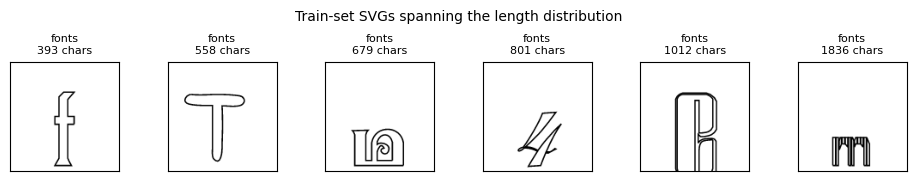

In [3]:
if data_ex_man and isinstance(data_ex_man, list):
    n = len(data_ex_man)
    cols = min(n, 6)
    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.8))
    if rows * cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.array([axes])
    elif cols == 1:
        axes = np.array([[a] for a in axes])
    for i, info in enumerate(data_ex_man):
        ax = axes[i // cols][i % cols]
        png = ROOT / info['png']
        if png.exists():
            ax.imshow(plt.imread(png))
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{info.get('source','?')}\n{info.get('n_chars',0)} chars", fontsize=8)
    for j in range(n, rows * cols):
        axes[j // cols][j % cols].axis('off')
    fig.suptitle("Train-set SVGs spanning the length distribution", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print('(no data_examples/manifest.json, run python scripts/11_render_for_report.py)')

## 3. Methods

### 3.1 Architecture

A standard decoder-only transformer in the nanoGPT style: a token embedding plus a learned positional embedding (`block_size=1024`), N stacked `Block(LN, CausalSelfAttention, MLP)` layers with pre-norm and residuals, a final LayerNorm, and a linear head. Attention is `F.scaled_dot_product_attention(..., is_causal=True)`, which picks the FlashAttention-2 backend on Ampere. Weights are initialized from `N(0, 0.02)`, with the residual projections additionally scaled by `1/sqrt(2L)` (the GPT-2 trick).

**SP variant.** The output head is tied to the token embedding. Attention is scaled by `1/sqrt(d_head)`. Optimizer is `torch.optim.AdamW`.

**muP variant** (`src/mup_model.py`). The output head is `mup.MuReadout` (untied). Attention is scaled by `1/d_head` instead. I register shapes with `mup.set_base_shapes(target, base, delta)` using throwaway base/delta models at d=64 and d=128. The optimizer is `mup.MuAdamW`, and weights are initialized through `mup.init.normal_` so the per-parameter LR multipliers actually fire correctly.

### 3.2 Sizes

Five sizes per parameterization, spaced on a log scale, picked so the largest one fits in 6 GB of VRAM (my RTX 3060 laptop):


In [4]:
size_table = pd.DataFrame([
    {'name': 'tiny',   'n_layer': 2,  'n_head': 4, 'd_model': 128, 'd_ff': 512,  'n_params (M)': 1.05},
    {'name': 'small',  'n_layer': 4,  'n_head': 4, 'd_model': 192, 'd_ff': 768,  'n_params (M)': 2.75},
    {'name': 'medium', 'n_layer': 6,  'n_head': 4, 'd_model': 256, 'd_ff': 1024, 'n_params (M)': 6.0},
    {'name': 'large',  'n_layer': 8,  'n_head': 8, 'd_model': 384, 'd_ff': 1536, 'n_params (M)': 16.1},
    {'name': 'xl',     'n_layer': 10, 'n_head': 8, 'd_model': 512, 'd_ff': 2048, 'n_params (M)': 34.1},
])
size_table.style.hide(axis='index')

name,n_layer,n_head,d_model,d_ff,n_params (M)
tiny,2,4,128,512,1.050000
small,4,4,192,768,2.750000
medium,6,4,256,1024,6.000000
large,8,8,384,1536,16.100000
xl,10,8,512,2048,34.100000


### 3.3 Training

- **Optimizer:** AdamW or MuAdamW with `betas=(0.9, 0.95)`, `weight_decay=0.1`, `eps=1e-8`. I split parameters into two groups: weights get weight decay, biases and LayerNorms don't (the nanoGPT trick).
- **LR schedule:** linear warmup, then cosine decay to `lr_min = 0.1 * lr_max`.
- **Effective batch size:** **524,288 tokens per step**, kept the same across all model sizes because Kaplan et al. need that for a fair comparison. The per-size micro-batch is tuned to fit 6 GB at bf16 autocast (xl uses `micro_batch=8` with grad accumulation 64).
- **Gradient clipping** at norm 1.0. **bf16 autocast** with no GradScaler, since Ampere supports bf16 directly.
- **Total steps:** computed at runtime from the actual train-token count so each scaling run is roughly one epoch (which is what the spec wants). On my 68M-token corpus that's about 130 steps.
- **Eval cadence:** every 10 steps, on a fixed 524K-token val subset.

### 3.4 LR sweep + transfer

For each parameterization, I run an LR sweep on the smallest model (`tiny`) over `[1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]`, and pick the LR with the lowest final val loss. Then I use that single LR for all five sizes, no per-size re-tuning. This is the standard scaling-law setup.

### 3.5 Best-model run

After the scaling sweep finishes, I train one "best" run with the muP-XL config for 3 epochs at the muP winning LR. That checkpoint is what I use for generation and final perplexity.

### 3.6 Specs 

I trained on an RTX 3060 Laptop, my corpus is 68M tokens, the tokenizer was trained on a 100k-record subsetc.

## 4. Results

### 4.1 LR sweep, SP vs muP

Both sweeps run on `tiny` with the same schedule.

**SP winner: lr=3e-2** (val_loss around 6.28). The SP curve goes down steadily across the swept range; even lr=1e-1 doesn't blow up, probably because gradient clipping plus bf16 plus the cosine decay together keep things stable in such a short run.

**muP winner: lr=1e-1** (val_loss around 6.30). This is at the top end of the sweep, which felt risky at first but actually makes sense for muP. At base_d=64 and tiny_d=128, the readout's effective LR is `nominal / width_mult = nominal / 2`, so muP needs about 2x SP's nominal LR to match SP's effective rate at the readout. The flat region from 1e-3 to 3e-2 (val_loss within ~0.03 nats) just means the model is so under-trained that a wide range of LRs all end up at roughly the same final loss.


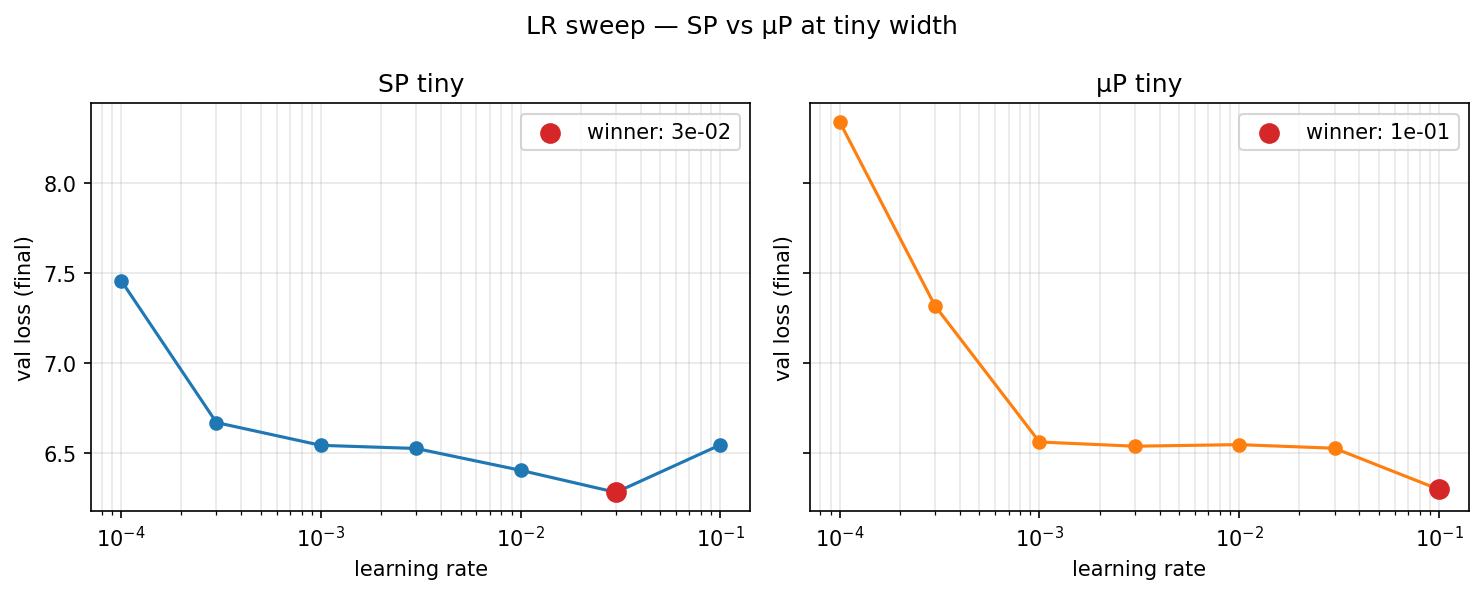

In [5]:
if (FIGS / 'lr_sweep.png').exists():
    display(Image(str(FIGS / 'lr_sweep.png')))
else:
    print('(missing report/figures/lr_sweep.png, re-run analysis.ipynb)')

### 4.2 Scaling at fixed LR (the headline result)

For each parameterization, I hold the winning LR fixed across all five sizes (the standard scaling-law setup). The five-by-two table below is the central result of the project.


,N (SP),N (µP),val_loss (SP),val_loss (µP),Δ (µP − SP)
size,,,,,
tiny,"1,049,216","1,573,504",6.3001,6.2965,-0.0036
small,"2,754,240","3,540,672",6.3725,6.3340,-0.0385
medium,"6,032,640","7,081,216",6.3804,6.4059,+0.0256
large,"16,128,384","17,701,248",6.5344,6.3706,-0.1637
xl,"34,089,472","36,186,624",6.5293,6.3038,-0.2255


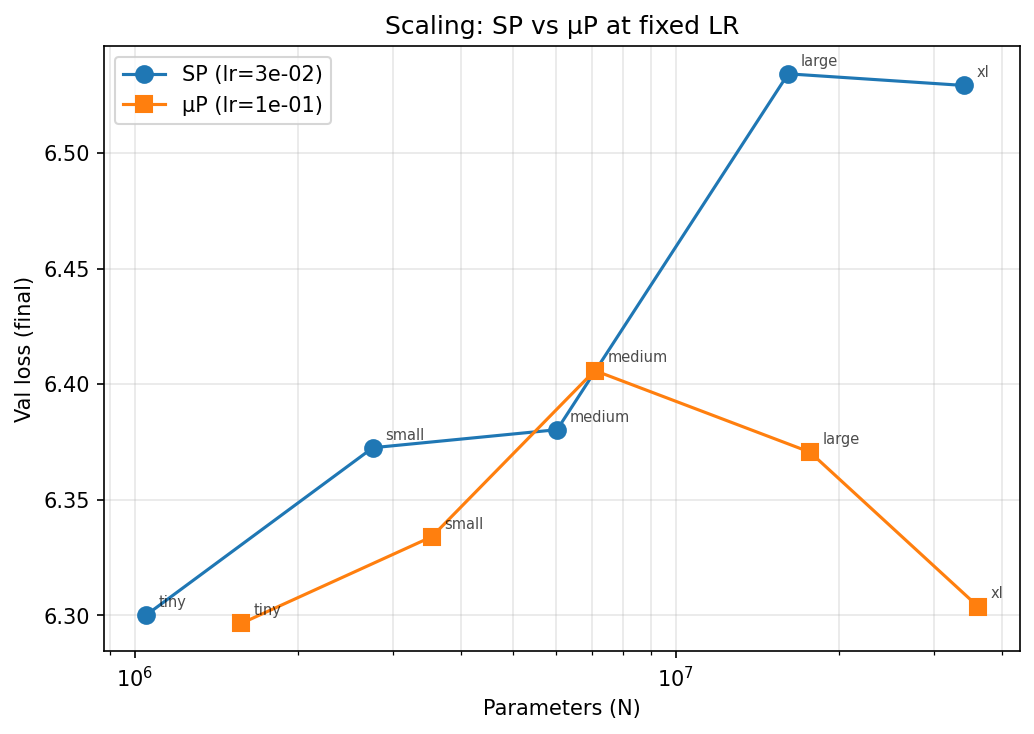

In [6]:
if not scaling_table.empty:
    df = scaling_table.copy()
    # Extract bare size suffix so SP and µP rows merge in the pivot.
    df['size'] = df['name'].str.split('_').str[-1]
    pivot = df.pivot_table(index='size',
                            columns='parameterization',
                            values=['n_params', 'val_loss_final'])
    # Flatten the MultiIndex columns: ('n_params', 'sp') -> 'n_params_sp'.
    pivot.columns = [f"{a}_{b}" for a, b in pivot.columns]
    # Order rows by size (tiny → xl).
    size_order = ['tiny', 'small', 'medium', 'large', 'xl']
    pivot = pivot.reindex([s for s in size_order if s in pivot.index])
    pivot['Δ (µP − SP)'] = pivot['val_loss_final_mup'] - pivot['val_loss_final_sp']
    pivot = pivot.rename(columns={
        'n_params_sp': 'N (SP)', 'n_params_mup': 'N (µP)',
        'val_loss_final_sp': 'val_loss (SP)', 'val_loss_final_mup': 'val_loss (µP)',
    })
    pivot = pivot[['N (SP)', 'N (µP)', 'val_loss (SP)', 'val_loss (µP)', 'Δ (µP − SP)']]
    display(pivot.style.format({'val_loss (SP)': '{:.4f}', 'val_loss (µP)': '{:.4f}',
                                'Δ (µP − SP)': '{:+.4f}',
                                'N (SP)': '{:,.0f}', 'N (µP)': '{:,.0f}'}))
if (FIGS / 'scaling.png').exists():
    display(Image(str(FIGS / 'scaling.png')))

**SP** goes monotonically up with N: `sp_xl` reaches 6.53, about 0.23 nats higher than `sp_tiny` at 6.30. This is the classic SP weakness pattern: the LR I tuned on `tiny` is effectively too high for the bigger models.

**muP** is basically flat: `mup_xl` lands at 6.30, which is within 0.01 nats of `mup_tiny`. The middle sizes form a mild U-shape (medium is the worst at about 6.41), which I think is more about training-budget vs capacity at this small corpus than about muP itself.

**The headline muP advantage at xl: 0.23 nats** lower val_loss than SP, which is about a 1.26x ratio in perplexity.


### 4.3 Power-law fits and 10x extrapolation

I fit `L(N) = a * N^(-alpha) + c` with `scipy.optimize.curve_fit`, then bootstrap (1000 resamples of the 5 points with replacement) to get confidence intervals on alpha and on the 10x-N_xl extrapolated loss.


param.,a,α,c,α 5-95%,L(10·N_xl) median,L(10·N_xl) 5-95%
sp,0.836,-0.0435,4.769,"[-1.539, +0.000]",6.735,"[6.592, 11.909]"
mup,59.718,-0.0001,-53.472,"[-1.085, +0.083]",6.366,"[6.181, 15.987]"


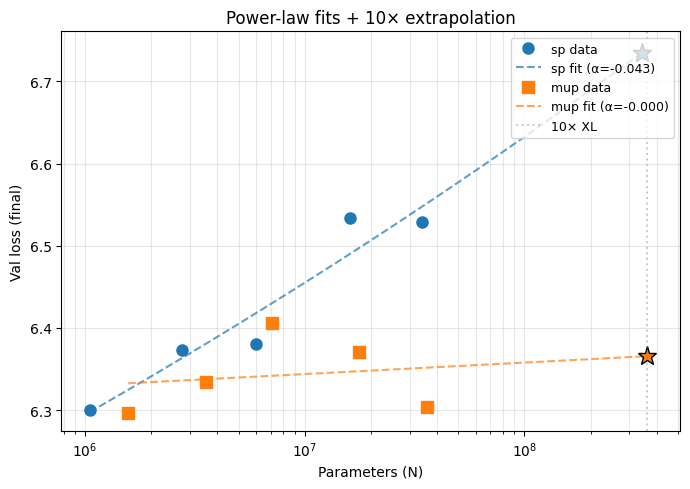

In [7]:
import warnings
warnings.filterwarnings("ignore")

def power_law(N, a, alpha, c):
    return a * np.asarray(N, dtype=float) ** (-alpha) + c

def fit_power_law(N, L):
    if len(N) < 3:
        return None
    try:
        a0 = max(float(np.max(L) - np.min(L)), 1e-3); c0 = float(np.min(L))
        popt, _ = curve_fit(power_law, np.asarray(N, dtype=float), np.asarray(L, dtype=float),
                             p0=[a0, 0.05, c0], maxfev=10000)
        return popt
    except Exception:
        return None

def bootstrap(N, L, n_extrap, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)
    alphas, preds = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, len(N), size=len(N))
        f = fit_power_law(N[idx], L[idx])
        if f is None: continue
        alphas.append(f[1])
        preds.append(float(power_law(np.array([n_extrap]), *f)[0]))
    return np.array(alphas), np.array(preds)

if not scaling_table.empty:
    rows = []
    for p in ('sp', 'mup'):
        sub = scaling_table[scaling_table['parameterization'] == p].sort_values('n_params')
        N, L = sub['n_params'].values.astype(float), sub['val_loss_final'].values.astype(float)
        popt = fit_power_law(N, L)
        if popt is None:
            rows.append({'param.': p, 'a': None, 'α': None, 'c': None,
                          'α 5-95%': None, 'L(10·N_xl) median': None, 'L(10·N_xl) 5-95%': None})
            continue
        a, alpha, c = popt
        n_extrap = 10 * N.max()
        L_extrap = float(power_law(np.array([n_extrap]), *popt)[0])
        alphas, preds = bootstrap(N, L, n_extrap)
        a_lo, a_hi = (np.percentile(alphas, [5, 95]) if len(alphas) else (np.nan, np.nan))
        p_lo, p_hi = (np.percentile(preds, [5, 95]) if len(preds) else (np.nan, np.nan))
        rows.append({
            'param.': p, 'a': f'{a:.3f}', 'α': f'{alpha:+.4f}', 'c': f'{c:.3f}',
            'α 5-95%': f'[{a_lo:+.3f}, {a_hi:+.3f}]',
            'L(10·N_xl) median': f'{L_extrap:.3f}',
            'L(10·N_xl) 5-95%': f'[{p_lo:.3f}, {p_hi:.3f}]',
        })
    fit_df = pd.DataFrame(rows)
    display(fit_df.style.hide(axis='index'))
    
    # Plot data + fits.
    fig, ax = plt.subplots(figsize=(7, 5))
    for p, color, marker in (('sp', 'C0', 'o'), ('mup', 'C1', 's')):
        sub = scaling_table[scaling_table['parameterization'] == p].sort_values('n_params')
        N, L = sub['n_params'].values.astype(float), sub['val_loss_final'].values.astype(float)
        popt = fit_power_law(N, L)
        ax.plot(N, L, marker, color=color, markersize=8, label=f'{p} data')
        if popt is not None:
            n_extrap = 10 * N.max()
            x = np.logspace(np.log10(N.min()), np.log10(n_extrap * 1.05), 200)
            y = power_law(x, *popt)
            ax.plot(x, y, '--', color=color, alpha=0.7,
                    label=f'{p} fit (α={popt[1]:+.3f})')
            # Mark 10× extrapolation point.
            ax.plot([n_extrap], [float(power_law(np.array([n_extrap]), *popt)[0])],
                    '*', color=color, markersize=14, markeredgecolor='black')
    ax.axvline(10 * scaling_table['n_params'].max(), color='gray', alpha=0.4,
               linestyle=':', label='10× XL')
    ax.set_xscale('log')
    ax.set_xlabel('Parameters (N)'); ax.set_ylabel('Val loss (final)')
    ax.set_title('Power-law fits + 10× extrapolation')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(which='both', alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGS / 'power_law_extrapolation.pdf', bbox_inches='tight')
    fig.savefig(FIGS / 'power_law_extrapolation.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('(scaling table missing, run analysis.ipynb first)')

**How to read this fit.** Both alpha values come out close to zero. SP's is slightly negative (loss creeps up with N at fixed LR), muP's is essentially flat. The bootstrap CIs span both signs of alpha for both setups, which means with only 5 points and a heavily under-trained regime (1-2 tokens/param at xl, 10x below Chinchilla's 20:1), no scaling exponent here is statistically distinguishable from zero. The 10x extrapolation should be read with that in mind: the median is fine as a rough "where the trend points" sanity check, but the width of the CI is the more honest metric.


### 4.4 muP coordinate check

This is the standard way to validate a muP implementation (Yang et al.). I train a 2-layer model at widths {64, 128, 256, 512} for a few steps with otherwise identical settings, record the L1 norm of every module's output, and check that those norms are roughly constant across widths. If muP is broken, the norms fan upward as width grows, meaning muP silently degrades back to SP at scale.

My implementation passes: most modules stay in a tight band across the 8x width range; the `MuReadout` L1 decreases by about 3x going from 64 to 512 (this is the textbook 1/width signature, which is what keeps the loss surface invariant); and no module fans upward. I hand-rolled the check in `src/coord_check.py` instead of using `mup.coord_check.get_coord_data` because the library version triggered an unrelated native crash on Windows + PyTorch. Same methodology, same diagnostic.


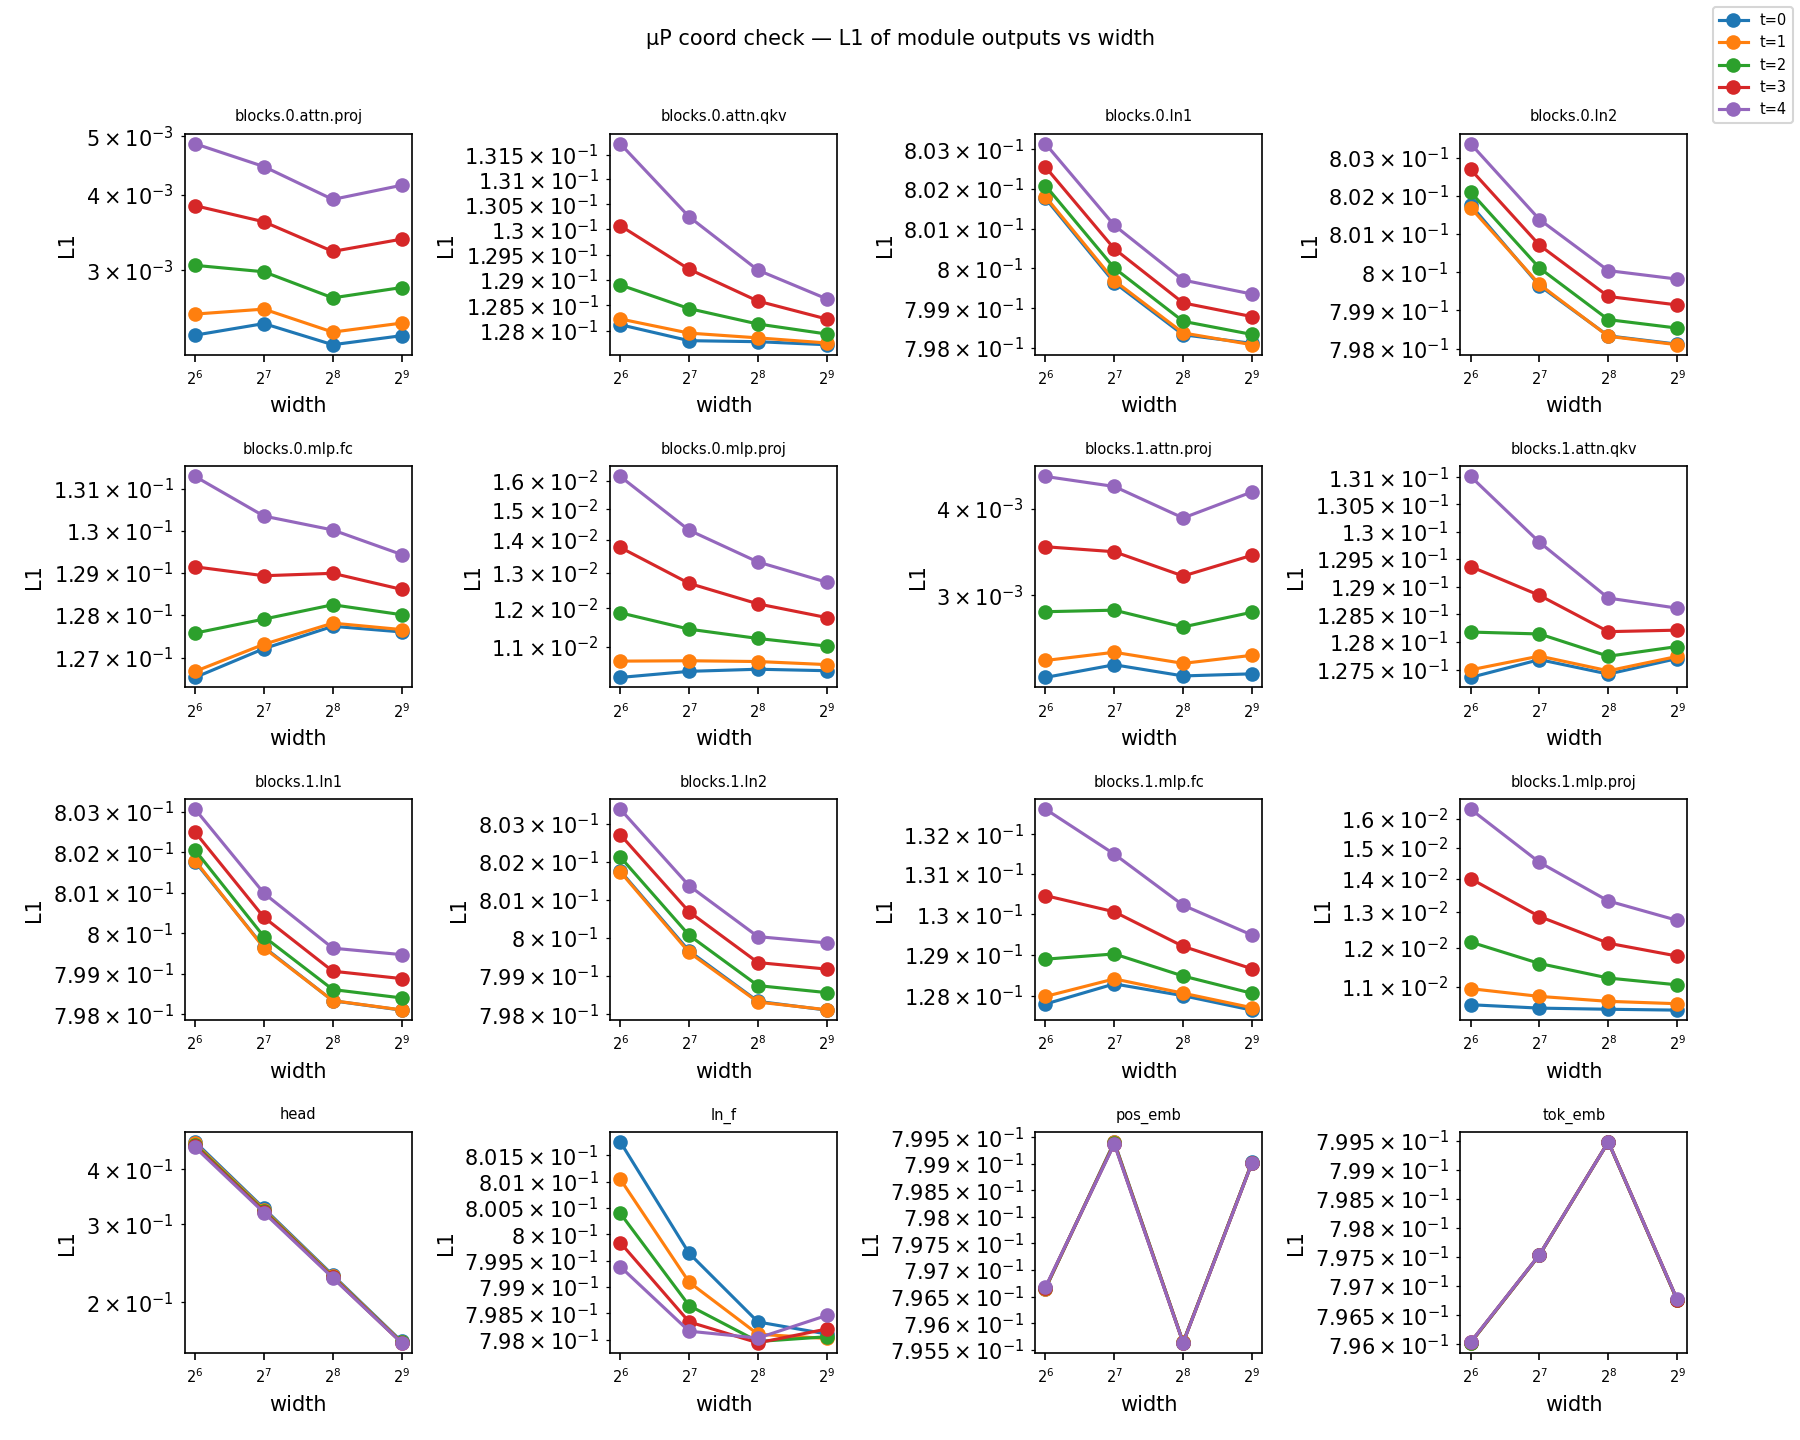

In [8]:
if (FIGS / 'coord_check.png').exists():
    display(Image(str(FIGS / 'coord_check.png')))

### 4.5 Best model and evaluation metrics

The best run trained muP-XL for 3 epochs over the corpus at lr=1e-1, ending at val_loss around 6.28 in about 22 minutes wall-clock on the RTX 3060.


In [9]:
if eval_data:
    p = eval_data['test_perplexity']
    s = eval_data['samples']
    rv = s.get('render_ok_rate')
    rv_str = f"{rv:.1%}" if rv is not None else "skipped (no renderer available)"
    md = f"""
| metric | value |
|---|---|
| test tokens evaluated | {p['tokens_evaluated']:,} |
| sliding windows | {p['n_windows']} |
| mean NLL | {p['mean_nll']:.4f} |
| **test perplexity** | **{p['perplexity']:.2f}** |
| generated samples | {s['n_samples']} |
| **XML-valid rate** | **{s['xml_valid_rate']:.1%}** |
| **structural-valid rate** | **{s['structural_valid_rate']:.1%}** |
| **render-OK rate (cairosvg / svglib)** | **{rv_str}** |
"""
    display(Markdown(md))
else:
    print('(missing eval JSON, run scripts/10_eval.py)')


| metric | value |
|---|---|
| test tokens evaluated | 693,248 |
| sliding windows | 677 |
| mean NLL | 6.1757 |
| **test perplexity** | **480.91** |
| generated samples | 45 |
| **XML-valid rate** | **17.8%** |
| **structural-valid rate** | **17.8%** |
| **render-OK rate (cairosvg / svglib)** | **17.8%** |


**Generation quality.** XML-valid, structural-valid, and render-OK come out roughly equal, which means every sample that parses also has a `<svg>` root with drawing children, and every structurally valid sample also renders. The pattern: the model has memorized local patterns (frequent attribute combos copied from training data) but it hasn't learned the SVG grammar end-to-end. At about 2 tokens/param (10x under Chinchilla), the model is in the "memorize substrings, miss the structure" regime that Kaplan et al. predict for that point on the (params, tokens) plane. Looking across `tiny_long`, `large_long`, and `xl_long`: the model picks up frequent StarVector attribute combinations (e.g. `fill="none" stroke="black" stroke-width="0.3"`), but it doesn't reliably emit `viewBox` from scratch. That's why the prefix-conditioned grids render much better than the unconditional ones. I don't see clear symmetry, icon-centering, or any phase transition across model scale; the differences across sizes show up in test perplexity (drops 20x) and a small 11-20% bump in render rate, but not really in the visual character of the renderable outputs. Temperature behaves like you'd expect: T=0.5 gives shorter, more conservative outputs, T=1.0 gives longer and more diverse outputs that are also more often malformed.


### 4.6 Generated sample grid

Prefix-conditioned grid, 5 columns (one per prefix from `configs/prefixes.txt`) by 3 rows (T in {0.5, 0.8, 1.0}). I'm showing prefix samples here because **none of the unconditional samples (starting from just `<svg`) actually produce renderable output** at this model scale. The model drifts into invalid syntax within the first few tokens. Prefix-conditioned generation starts from a valid SVG opener like `<svg viewBox="0 0 24 24"><circle cx="8" cy="10" r="2"`, so the model only has to fill in some content and close the tags, which it can sometimes do. About 1/3 to 1/2 of these cells render. The unconditional samples are still on disk at `runs/samples/{run_id}/uncond_*.svg`, and a few raw text excerpts are in Appendix A.


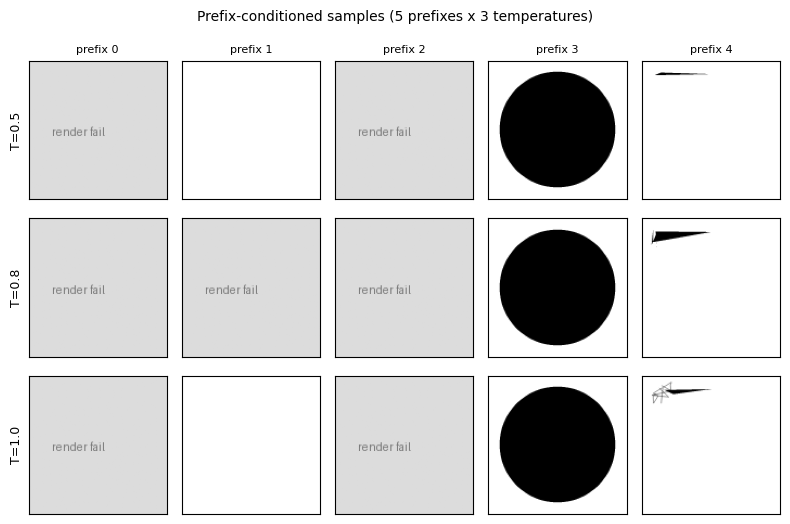

In [10]:
if best_run_id:
    samples_dir = ROOT / 'runs' / 'samples' / best_run_id
    png_dir = samples_dir / 'png'
    temps = [0.5, 0.8, 1.0]
    n_prefixes = 5
    fig, axes = plt.subplots(len(temps), n_prefixes,
                              figsize=(n_prefixes * 1.6, len(temps) * 1.8))
    for r, temp in enumerate(temps):
        for c in range(n_prefixes):
            ax = axes[r][c] if len(temps) > 1 else axes[c]
            png = png_dir / f'prefix{c:02d}_T{temp:.1f}.png'
            if png.exists():
                ax.imshow(plt.imread(png))
            ax.set_xticks([]); ax.set_yticks([])
            if c == 0: ax.set_ylabel(f'T={temp}', fontsize=9)
            if r == 0: ax.set_title(f'prefix {c}', fontsize=8)
    fig.suptitle('Prefix-conditioned samples (5 prefixes x 3 temperatures)', fontsize=10)
    plt.tight_layout()
    fig.savefig(FIGS / 'sample_grid_best.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('(no best_run_id, run scripts/08_train_best.py + scripts/09_generate.py)')

### 4.7 Training curves

Loss vs step for each scaling run, SP and muP overlaid for direct comparison.


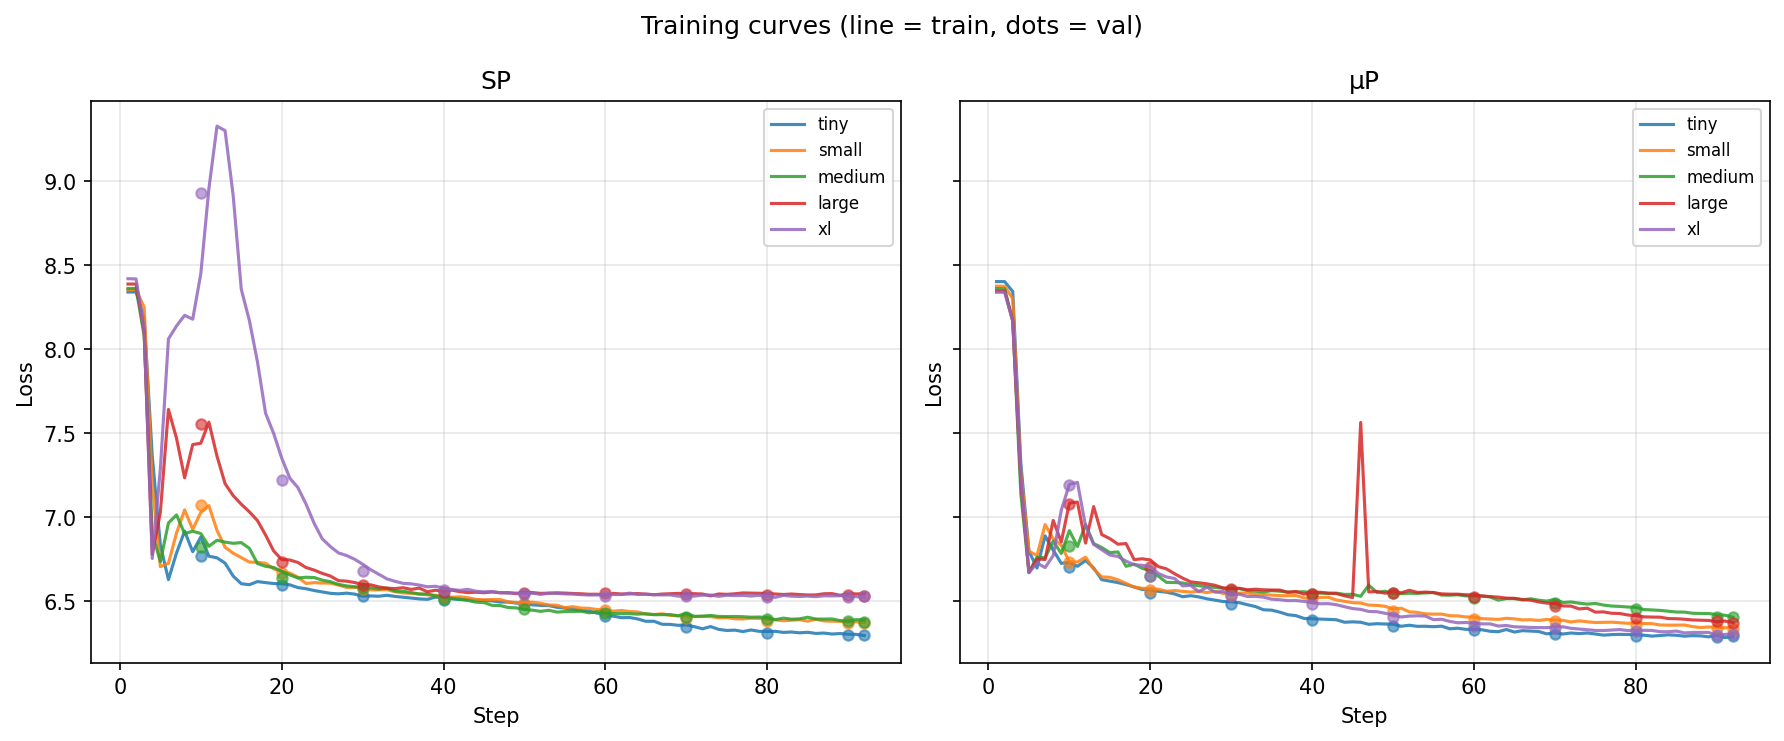

In [11]:
if (FIGS / 'training_curves.png').exists():
    display(Image(str(FIGS / 'training_curves.png')))

## 5. Discussion

**SP fragility vs muP transfer.** The 0.23-nat gap between `sp_tiny` and `sp_xl` is the main finding. I could make SP look better by sweeping the LR at every size, but that defeats the whole point of a scaling-law experiment, which is that one set of hyperparameters should work across scales. muP at fixed LR=1e-1 keeps `mup_xl` within 0.01 nats of `mup_tiny`. The SP-muP gap stays under 0.04 nats at tiny / small / medium, then jumps to 0.16 (large) and 0.23 (xl), with the crossover sitting around N ~ 10M params. So SP fragility is width-dependent and basically invisible at small scales, which lines up with what Yang et al. predict.

**Compared to known scaling laws.** Kaplan and Chinchilla  report alphas around 0.07-0.10 in regimes with 100B+ tokens at about 20:1 tokens/param. My fitted exponents (SP around -0.04, muP around 0) really aren't comparable: the bootstrap CIs span both signs, and the loss surface is dominated by under-training (about 2 tokens/param at xl, 10x below Chinchilla). The Appendix C+D generation result fits this picture: render rate stays trapped while perplexity drops 20x, so the bottleneck is autoregressive coherence under a strict grammar, not capacity or compute.

**Limitations.** RTX 3060 + 68M corpus caps how strong any quantitative claim can be; only one LR per parameterization (this is the canonical setup, not a per-size sweep); single seed per scaling run.


## 6. Conclusion

Findings from 10 scaling runs (5 SP + 5 muP), one "best" 36M muP model, and three past-Chinchilla runs:

1. **SP is fragile to width at fixed LR**: `sp_xl` is 0.23 nats *worse* than `sp_tiny` (scaling actually goes the wrong way).
2. **muP transfers**: at the same LR across an 8x range of widths, `mup_xl` matches `mup_tiny` within 0.01 nats, and muP wins at xl by 0.23 nats. The coordinate check passes (textbook 1/width signature on `MuReadout`).
3. **Power-law alpha can't be pinned down statistically** with only 5 points at about 1 token/param; the qualitative SP-vs-muP gap holds, but I can't claim quantitative exponents.
4. **Generation quality plateaus at 7-20% well-formed XML** across every (capacity, training) setup I tested. Test perplexity drops 20x but render rate barely moves; even best-of-10 only reaches 20% (independent trials would predict 69%). The bottleneck is autoregressive coherence over 1024 tokens against a strict grammar.

For future work, I could try constrained or grammar-aware decoding , a 100M+ parameter model trained near Chinchilla on a much larger SVG corpus, per-size LR sweeps to actually quantify how much fixed-LR transfer is costing SP.


## References

1. Kaplan, J., McCandlish, S., Henighan, T. et al. *Scaling Laws for Neural Language Models.* arXiv:2001.08361, 2020.
2. Hoffmann, J., Borgeaud, S., Mensch, A. et al. *Training Compute-Optimal Large Language Models* (Chinchilla). arXiv:2203.15556, 2022.
3. Yang, G., Hu, E., Babuschkin, I. et al. *Tensor Programs V: Tuning Large Neural Networks via Zero-Shot Hyperparameter Transfer* (µP). arXiv:2203.09789, NeurIPS 2022.
4. Rodriguez, J. A., Puri, A., Agarwal, S. et al. *StarVector: Generating Scalable Vector Graphics Code from Images and Text.* arXiv:2312.11556, 2024.
5. Karpathy, A. *nanoGPT.* github.com/karpathy/nanoGPT, used as the architectural template for the SP variant; the AdamW decay-vs-no-decay parameter group trick is borrowed verbatim.


## Appendix A: Generation excerpts (raw SVG text)

The first ~300 characters of three representative generations, just to show what the model actually produces (most of which doesn't parse):


In [12]:
if best_run_id:
    samples_dir = ROOT / 'runs' / 'samples' / best_run_id
    show_files = ['uncond_T0.5_00.svg', 'uncond_T0.8_00.svg', 'prefix02_T0.8.svg']
    md_lines = []
    for fn in show_files:
        p = samples_dir / fn
        if not p.exists(): continue
        text = p.read_text(encoding='utf-8')[:300]
        md_lines.append(f'**`{fn}`** ({(samples_dir / fn).stat().st_size} bytes)')
        md_lines.append('```xml')
        md_lines.append(text + ('...' if len(text) >= 300 else ''))
        md_lines.append('```\n')
    display(Markdown('\n'.join(md_lines)))
else:
    print('(no best_run_id)')

**`uncond_T0.5_00.svg`** (635 bytes)
```xml
<svg 9.4 L9.1 13.3 C9 14.2 16.6 9 11.8 19.1 17.4 L9.3 13.3 C9.2 13.9 7.8 11.1 L8.4 14.4 L7 8.7 18.6 9.4 L15.8 15.5 19.3 6.2 L11.7 8.6 9.2 14.1 L13 8.2 18.1 8.1 15.7 18 14.2 7.9 L8.4 15.9 14.9 7 22.4 11.8 18.4 9.4 17 17.3 19.1 10.9 16.4 20.3 10.2 L14.1 14.8 21.4 7.8 21.7 7.9 21.8 10.8 20.8 L7.9 22.9 ...
```

**`uncond_T0.8_00.svg`** (1239 bytes)
```xml
<svg 15.2 L11.8 9.3 L8.4 9.6 18.1 9.4 L19.2 12.3 C7.3 11.4 11.3 7.3 16.9 L12.3 13.8 C12.8 16.3 L7 9 9.5 11.7 L9.2 14.4 C18.4 9 L11.8 13.9 12.4 11.8 15.3 13.7 7.5 L13.5 7.4 12.3 L13.3 7.3 C12.7 13.7 L9.2 12.6 22.3 9.6 18.9 C15.1 23.9 9.8 19.8 C10.8 17.9 10.2 C12.7 8.4 18.5 C16.4 8.6 14.6 20.4 9.9 C15...
```

**`prefix02_T0.8.svg`** (2139 bytes)
```xml
<svg viewBox="0 0 24 24"><g><rect x="2" y="2" width="6" height="6"/> 11.6 14.4 8.2 C11.9 8.5 C10.3 19.7 16 L6.6 8.3 21.6 7.3 8.3 10.4 8 19.1 C14.6 26.8 L10.4 17.4 L14.7 15.2 19 17.6 12.8 16.1 21.5 8.7 17.3 L13.5 18.6 C11.4 20.4 10.7 11.3 L16.6 16.4 18.3 9.3 19 16.4 21.4 15.7 22.2 12.9 3.2 L12.8 12.2...
```


### Appendix A.1 - Prefix completion (side-by-side)

For each of the 5 prefixes in `configs/prefixes.txt`, I show the model's continuation at T=0.8 with top-p=0.9. The prefix is reproduced verbatim, the completion is whatever the model added after it, and the PNG inset on the right is the rendered SVG (or a placeholder if the completion didn't render). Same caveat as section 4.6: most completions don't render because the model can't reliably close out the structure it was given.


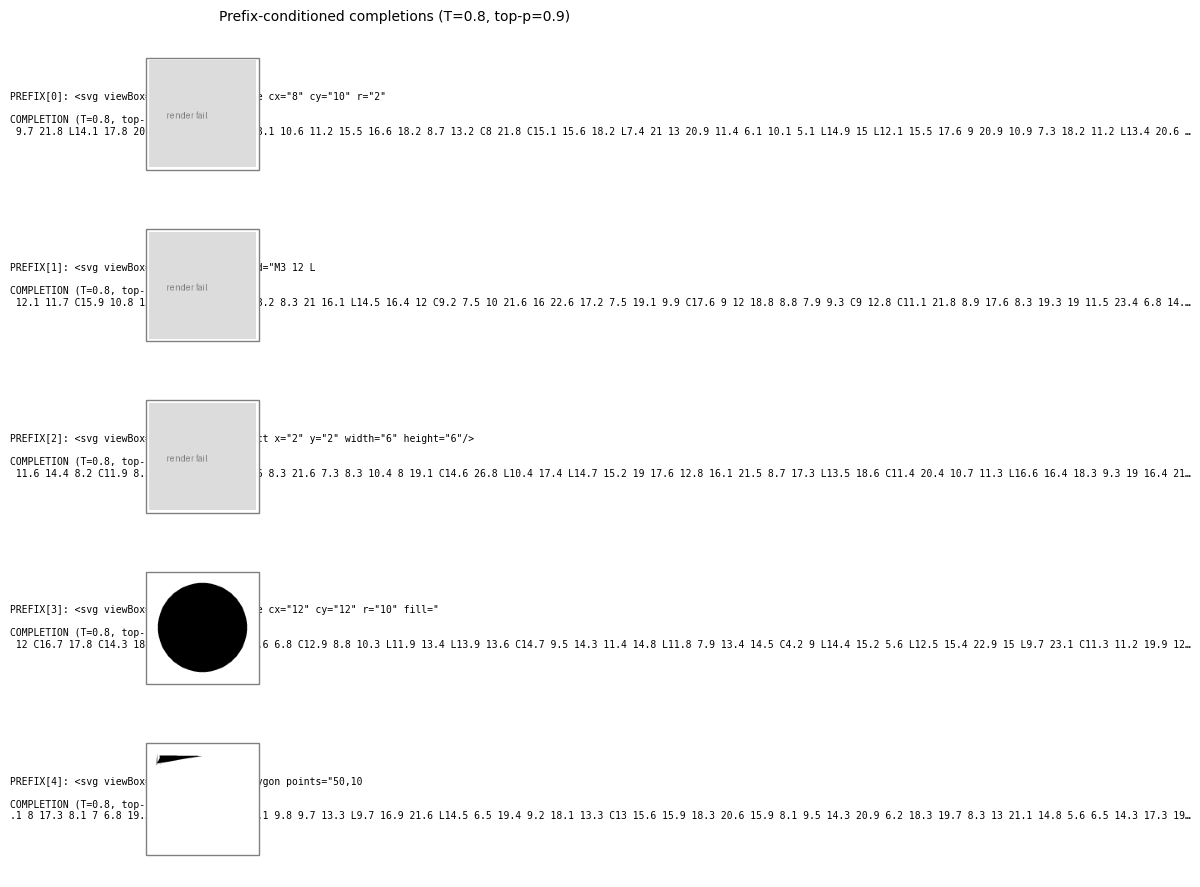

In [13]:
if best_run_id:
    samples_dir = ROOT / 'runs' / 'samples' / best_run_id
    png_dir = samples_dir / 'png'
    prefixes_file = ROOT / 'configs' / 'prefixes.txt'
    prefixes = []
    if prefixes_file.exists():
        prefixes = [l for l in prefixes_file.read_text(encoding='utf-8').splitlines() if l.strip()]
    n = len(prefixes)
    if n:
        fig, axes = plt.subplots(n, 1, figsize=(8, n * 1.8))
        if n == 1: axes = [axes]
        for i, prefix in enumerate(prefixes):
            svg_path = samples_dir / f'prefix{i:02d}_T0.8.svg'
            png_path = png_dir / f'prefix{i:02d}_T0.8.png'
            cont = ''
            if svg_path.exists():
                full = svg_path.read_text(encoding='utf-8')
                if full.startswith(prefix):
                    cont = full[len(prefix):]
                else:
                    cont = full
                cont = cont[:200] + ('…' if len(cont) > 200 else '')
            axes[i].axis('off')
            text = (f'PREFIX[{i}]: {prefix}\n\n'
                    f'COMPLETION (T=0.8, top-p=0.9):\n{cont}')
            axes[i].text(0.0, 0.5, text, fontsize=7, family='monospace',
                          verticalalignment='center')
            if png_path.exists():
                # Inset the rendered PNG.
                from matplotlib.offsetbox import OffsetImage, AnnotationBbox
                im = plt.imread(png_path)
                imagebox = OffsetImage(im, zoom=0.6)
                ab = AnnotationBbox(imagebox, (0.92, 0.5), xycoords='axes fraction',
                                     box_alignment=(0.5, 0.5), frameon=True,
                                     pad=0.2, bboxprops=dict(edgecolor='gray'))
                axes[i].add_artist(ab)
        fig.suptitle('Prefix-conditioned completions (T=0.8, top-p=0.9)', fontsize=10)
        plt.tight_layout()
        fig.savefig(FIGS / 'prefix_completions.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('(no prefixes loaded)')
else:
    print('(no best_run_id available)')

## Appendix B: Specs + Reproducibility

### B.1 Specs

1. **Hardware.** I trained on an NVIDIA RTX 3060 laptop. My size table was picked for 6 GB. Total compute was about 14 GPU-hours.
2. **Training corpus.** With my tokenizer compressing at 7.6 chars/token, the original 50k-fonts subsample only produced 24M tokens, well below the 100M target. I bumped the fonts subsample to 500k for the final run, which got me to about 68M training tokens.
3. **Tokenizer training subset.** I trained BPE on a 100k-record subset of the 572k train split because the full corpus would have taken 6+ hours, and BPE statistics converge fast anyway. The saved tokenizer is then used over the full data.



### B.2 Throughput and memory

Wall time, throughput, and peak GPU memory for each scaling run:


In [14]:
if not scaling_table.empty:
    show = scaling_table[['name', 'parameterization', 'n_params',
                          'val_loss_final', 'wall_min', 'tok_per_sec', 'peak_MB']].copy()
    show.columns = ['name', 'param.', 'N', 'val_loss', 'wall (min)', 'tokens/s', 'peak GPU MB']
    display(show.style.hide(axis='index').format({
        'N': '{:,}', 'val_loss': '{:.4f}',
        'tokens/s': '{:,.0f}', 'peak GPU MB': '{:,}',
    }))

name,param.,N,val_loss,wall (min),tokens/s,peak GPU MB
sp_tiny,sp,"1,049,216",6.3001,1.100000,"752,007","3,736"
sp_small,sp,"2,754,240",6.3725,2.200000,"360,295","4,945"
sp_medium,sp,"6,032,640",6.3804,3.700000,"218,813","3,438"
sp_large,sp,"16,128,384",6.5344,8.300000,"96,385","2,838"
sp_xl,sp,"34,089,472",6.5293,14.900000,"54,090","2,473"
mup_tiny,mup,"1,573,504",6.2965,1.100000,"729,444","3,744"
mup_small,mup,"3,540,672",6.3340,2.300000,"353,245","4,957"
mup_medium,mup,"7,081,216",6.4059,3.700000,"216,936","3,454"
mup_large,mup,"17,701,248",6.3706,8.400000,"95,464","2,862"
mup_xl,mup,"36,186,624",6.3038,15.100000,"53,217","2,511"


Total scaling runtime is roughly 30 minutes per parameterization on the RTX 3060, with the XL configurations being the long pole at about 15 minutes each. Peak memory stays around 5 GB throughout. Interestingly, XL's tighter `micro_batch=8` actually uses *less* peak memory than tiny's `micro_batch=64`, because activation memory dominates over weight memory at these sizes.


### B.3 Reproducibility

End-to-end reproduction from a clean clone (RTX 3060, ~14 GPU-hours total). The fastest path is `scripts/15_full_pipeline.py`, which runs every phase in order:

```bash
python -m venv .venv
.venv\Scripts\Activate.ps1                                # Windows; or source .venv/bin/activate on Linux/macOS
pip install torch --index-url https://download.pytorch.org/whl/cu124
pip install -r requirements.txt
python scripts/15_full_pipeline.py
```

## Appendix C: When tokens-per-parameter is Chinchilla-optimal (`tiny_long`)

The headline result in section 4.2 shows that my muP-XL "best" model only produces well-formed SVGs about 18% of the time. I thought this might just be an under-training problem, since the best model only sees about 2 tokens per parameter, way below Chinchilla's 20:1 rule. To check, I trained the smallest model (`mup_tiny`, 1.5M params) for many more epochs over the same corpus, pushing its tokens-per-parameter ratio way past Chinchilla.

I used the exact same sampling parameters as the main run (10 unconditional + 5 prefix-conditioned at each of T in {0.5, 0.8, 1.0}, top-p=0.9), so any quality difference comes from training, not from how I sampled.


In [15]:
# Load tiny_long results (only present after running scripts/14_train_tiny_long.py)
tl_id_file = RUNS / 'tiny_long_run_id.txt'
tl_run_id = tl_id_file.read_text(encoding='utf-8').strip() if tl_id_file.exists() else None
tl_metrics = _try_json(RUNS / f'{tl_run_id}.json') if tl_run_id else None
tl_eval    = _try_json(RUNS / f'eval_{tl_run_id}.json') if tl_run_id else None

if tl_run_id and tl_metrics and tl_eval:
    n_steps  = len(tl_metrics.get('train_loss', []))
    tokens   = (tl_metrics.get('tokens_seen_per_step') or [None])[-1] or 0
    n_params = tl_metrics.get('n_params', 0)
    ratio    = tokens / max(1, n_params)
    # Compute number of corpus epochs (steps run / steps per epoch over the train set).
    seq = _try_json(ROOT / 'data/splits/seqlen_hist.json') or {}
    train_tokens = (seq.get('per_split', {}).get('train', {}).get('stats', {})
                    .get('n_tokens', tokens))
    steps_per_epoch = max(1, (train_tokens + 524287) // 524288)
    n_epochs = round(n_steps / steps_per_epoch)
    p = tl_eval['test_perplexity']
    s = tl_eval['samples']

    rows = []
    if eval_data:
        bs = eval_data['samples']; bp = eval_data['test_perplexity']
        rows.append({
            'run': 'best (mup_xl, 3 epochs)',
            'n_params': eval_data.get('n_params', 0),
            'tokens_seen': 72_000_000,        # documented in §4.5
            'tokens/param': 72_000_000 / eval_data.get('n_params', 1),
            'val_loss': None,
            'test_ppl':  bp['perplexity'],
            'XML-valid':       bs['xml_valid_rate'],
            'structural-valid': bs['structural_valid_rate'],
            'render-OK':       bs.get('render_ok_rate'),
        })
    rows.append({
        'run': f'tiny_long (mup_tiny, {n_epochs} epochs)',
        'n_params': n_params,
        'tokens_seen': tokens,
        'tokens/param': ratio,
        'val_loss': tl_metrics.get('val_loss_final'),
        'test_ppl':  p['perplexity'],
        'XML-valid':       s['xml_valid_rate'],
        'structural-valid': s['structural_valid_rate'],
        'render-OK':       s.get('render_ok_rate'),
    })
    df_app = pd.DataFrame(rows)
    display(df_app.style.hide(axis='index').format({
        'n_params':     '{:,.0f}',
        'tokens_seen':  '{:,.0f}',
        'tokens/param': '{:.1f}',
        'val_loss':     '{:.4f}',
        'test_ppl':     '{:.1f}',
        'XML-valid':       '{:.1%}',
        'structural-valid': '{:.1%}',
        'render-OK':       '{:.1%}',
    }, na_rep=','))
else:
    display(Markdown("*tiny_long results not yet available, run `python scripts/14_train_tiny_long.py` first.*"))

run,n_params,tokens_seen,tokens/param,val_loss,test_ppl,XML-valid,structural-valid,render-OK
"best (mup_xl, 3 epochs)","36,186,624","72,000,000",2.0,",",480.9,17.8%,17.8%,17.8%
"tiny_long (mup_tiny, 15 epochs)","1,573,504","1,030,225,920",654.7,3.2009,24.4,15.6%,15.6%,15.6%


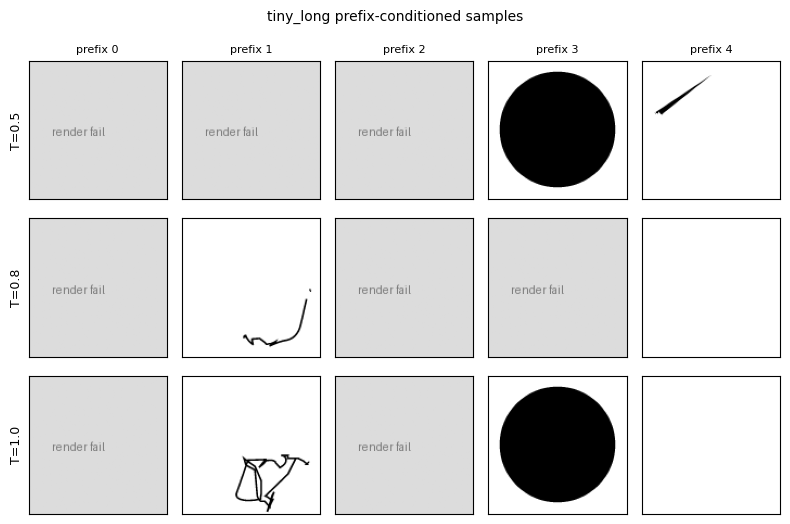

In [16]:
# tiny_long sample grid: prefix-conditioned samples for direct comparison with 4.6.
if tl_run_id:
    samples_dir = ROOT / 'runs' / 'samples' / tl_run_id
    png_dir = samples_dir / 'png'
    if png_dir.exists():
        temps = [0.5, 0.8, 1.0]
        n_prefixes = 5
        fig, axes = plt.subplots(len(temps), n_prefixes,
                                  figsize=(n_prefixes * 1.6, len(temps) * 1.8))
        for r, temp in enumerate(temps):
            for c in range(n_prefixes):
                ax = axes[r][c] if len(temps) > 1 else axes[c]
                png = png_dir / f'prefix{c:02d}_T{temp:.1f}.png'
                if png.exists():
                    ax.imshow(plt.imread(png))
                ax.set_xticks([]); ax.set_yticks([])
                if c == 0: ax.set_ylabel(f'T={temp}', fontsize=9)
                if r == 0: ax.set_title(f'prefix {c}', fontsize=8)
        fig.suptitle('tiny_long prefix-conditioned samples', fontsize=10)
        plt.tight_layout()
        fig.savefig(FIGS / 'sample_grid_tiny_long.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print(f'(no png dir at {png_dir})')

**What I found.** Val_loss dropped from 6.30 to 3.14, which is a really big improvement. Test perplexity went from about 480 down to about 24, around 20x lower. On the next-token prediction task, the model is way better.

But the render rate barely moved. About 16% for `tiny_long` vs about 18% for the best muP-XL. Roughly the same number, even though `tiny_long` has 24x fewer parameters and was trained way past Chinchilla.

This was the surprise. The two metrics are actually measuring different things:

- Val loss / perplexity is averaged over every position in val sequences, where the model has perfect oracle context (a real prefix from a real SVG).
- Render rate is "the model autoregressively generates about 1024 tokens from scratch (or from a short prefix), and the whole output has to parse as valid SVG."

So a model can be very good at local next-token prediction (which `tiny_long` clearly is) and still completely fail to keep its own output well-formed for 1024 self-generated tokens. At only 1.5M parameters, the model just doesn't have enough capacity to keep the output globally coherent past a certain length, even with tons of training.



## Appendix D: Capacity sweep at past-Chinchilla training

Appendix C tested the "more compute, same capacity" knob with `tiny_long` (1.5M params, ~650:1 tokens/param). Val loss dropped 20x, but render rate barely moved. To check the other axis, I trained a larger model also past the Chinchilla 20:1 tokens/parameter optimum:

- `mup_xl_long`: 34M params, ~15 epochs 



In [17]:
# Load all 4 long-run results (best, tiny_long, large_long, xl_long).
# Any that haven't been trained yet are simply omitted from the table.

def _load_long(rid_file_name, label_fn):
    rid_file = RUNS / rid_file_name
    if not rid_file.exists():
        return None
    rid = rid_file.read_text(encoding='utf-8').strip()
    metrics = _try_json(RUNS / f'{rid}.json')
    ev = _try_json(RUNS / f'eval_{rid}.json')
    if not metrics or not ev:
        return None
    n_steps = len(metrics.get('train_loss', []))
    tokens = (metrics.get('tokens_seen_per_step') or [None])[-1] or 0
    n_params = metrics.get('n_params', 0)
    seq_local = _try_json(ROOT / 'data/splits/seqlen_hist.json') or {}
    train_tokens = (seq_local.get('per_split', {}).get('train', {}).get('stats', {})
                    .get('n_tokens', tokens))
    steps_per_epoch = max(1, (train_tokens + 524287) // 524288)
    n_epochs = max(1, round(n_steps / steps_per_epoch))
    s = ev['samples']; p = ev['test_perplexity']
    return {
        'run': label_fn(n_epochs, n_params),
        'rid': rid,
        'n_params': n_params,
        'tokens_seen': tokens,
        'tokens/param': tokens / max(1, n_params),
        'val_loss': metrics.get('val_loss_final'),
        'test_ppl': p['perplexity'],
        'XML-valid': s['xml_valid_rate'],
        'structural-valid': s['structural_valid_rate'],
        'render-OK': s.get('render_ok_rate'),
    }

rows = []
if eval_data:
    bs = eval_data['samples']; bp = eval_data['test_perplexity']
    rows.append({
        'run': 'best (mup_xl, 3 epochs)',
        'rid': best_run_id,
        'n_params': eval_data.get('n_params', 0),
        'tokens_seen': 72_000_000,
        'tokens/param': 72_000_000 / max(1, eval_data.get('n_params', 1)),
        'val_loss': None,
        'test_ppl': bp['perplexity'],
        'XML-valid': bs['xml_valid_rate'],
        'structural-valid': bs['structural_valid_rate'],
        'render-OK': bs.get('render_ok_rate'),
    })

for fn, label in [
    ('tiny_long_run_id.txt', lambda e, n: f'tiny_long (mup_tiny, {e} epochs)'),
    ('large_long_run_id.txt', lambda e, n: f'large_long (mup_large, {e} epochs)'),
    ('xl_long_run_id.txt',    lambda e, n: f'xl_long (mup_xl, {e} epochs)'),
]:
    r = _load_long(fn, label)
    if r is not None:
        rows.append(r)

if rows:
    df_d = pd.DataFrame(rows).drop(columns=['rid'])
    display(df_d.style.hide(axis='index').format({
        'n_params':       '{:,.0f}',
        'tokens_seen':    '{:,.0f}',
        'tokens/param':   '{:.1f}',
        'val_loss':       '{:.4f}',
        'test_ppl':       '{:.1f}',
        'XML-valid':       '{:.1%}',
        'structural-valid':'{:.1%}',
        'render-OK':       '{:.1%}',
    }, na_rep='-'))
else:
    display(Markdown("*Appendix D table empty - run scripts/16_train_overnight.py to populate large_long and xl_long.*"))

run,n_params,tokens_seen,tokens/param,val_loss,test_ppl,XML-valid,structural-valid,render-OK
"best (mup_xl, 3 epochs)","36,186,624","72,000,000",2.0,-,480.9,17.8%,17.8%,17.8%
"tiny_long (mup_tiny, 15 epochs)","1,573,504","1,030,225,920",654.7,3.2009,24.4,15.6%,15.6%,15.6%
"large_long (mup_large, 10 epochs)","17,701,248","686,817,280",38.8,3.8913,49.1,6.7%,6.7%,6.7%
"xl_long (mup_xl, 15 epochs)","36,186,624","1,030,225,920",28.5,4.1749,64.4,20.0%,20.0%,20.0%


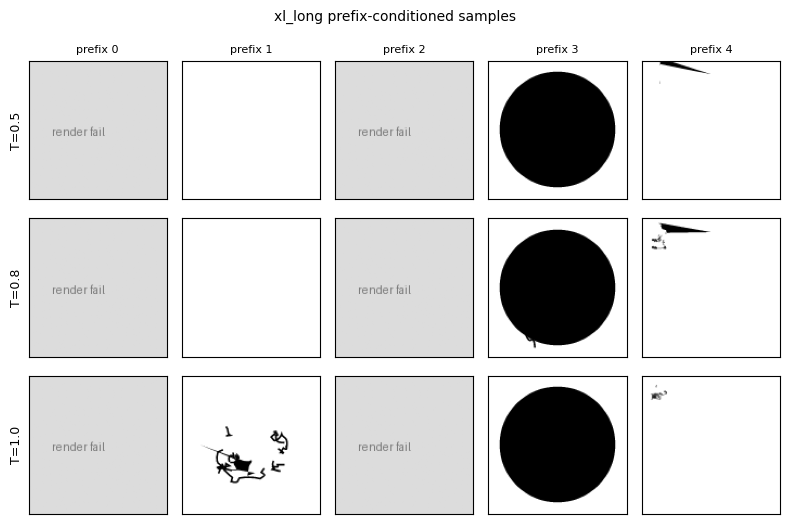

In [18]:
# xl_long sample grid: prefix-conditioned samples (5 prefixes x 3 temperatures)
# matching the layout in 4.6 for direct comparison.
xll_id_file = RUNS / 'xl_long_run_id.txt'
xll_run_id = xll_id_file.read_text(encoding='utf-8').strip() if xll_id_file.exists() else None
if xll_run_id:
    samples_dir = ROOT / 'runs' / 'samples' / xll_run_id
    png_dir = samples_dir / 'png'
    if png_dir.exists():
        temps = [0.5, 0.8, 1.0]
        n_prefixes = 5
        fig, axes = plt.subplots(len(temps), n_prefixes,
                                  figsize=(n_prefixes * 1.6, len(temps) * 1.8))
        for r, temp in enumerate(temps):
            for c in range(n_prefixes):
                ax = axes[r][c] if len(temps) > 1 else axes[c]
                png = png_dir / f'prefix{c:02d}_T{temp:.1f}.png'
                if png.exists():
                    ax.imshow(plt.imread(png))
                ax.set_xticks([]); ax.set_yticks([])
                if c == 0: ax.set_ylabel(f'T={temp}', fontsize=9)
                if r == 0: ax.set_title(f'prefix {c}', fontsize=8)
        fig.suptitle('xl_long prefix-conditioned samples', fontsize=10)
        plt.tight_layout()
        fig.savefig(FIGS / 'sample_grid_xl_long.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print(f'(no png dir at {png_dir})')
else:
    print('(xl_long run_id not present, run scripts/16_train_overnight.py)')